<a href="https://colab.research.google.com/github/mufadah/2026_Kecerdasan_Buatan/blob/main/Jobsheet10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Percobaan 1: Support Vector Machine (SVM) Klasifikasi

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    # 1. Membaca file diabetes.csv
    df = pd.read_csv('diabetes.csv')

    # 2. Melihat 5 baris pertama & info dataset
    print("--- 5 Baris Pertama ---")
    display(df.head())
    print("\n--- Info Dataset ---")
    df.info()

    # 3. Memisahkan atribut (X) dan label (y)
    X = df[df.columns[:8]]
    y = df['Outcome']

    # 4. Standarisasi fitur agar memiliki skala yang sama
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 5. Memisahkan data training dan testing (33% testing, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)

    # 6. Membuat objek SVC dan melatih model
    clf = SVC()
    clf.fit(X_train, y_train)

    # 7. Menguji akurasi model
    akurasi_svm = clf.score(X_test, y_test)
    print(f"\nAkurasi Model SVM: {akurasi_svm * 100:.2f}%")

except FileNotFoundError:
    print("Error: File 'diabetes.csv' belum diunggah ke Colab.")

--- 5 Baris Pertama ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Akurasi Model SVM: 75.59%


# Percobaan 2: Support Vector Regression (SVR)

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun_Pengalaman  30 non-null     float64
 1   Gaji              30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes

--- 5 Baris Pertama ---


,Tahun_Pengalaman,Gaji
0,1.1,590145000
1,1.3,693075000
2,1.5,565965000
3,2.0,652875000
4,2.2,598365000


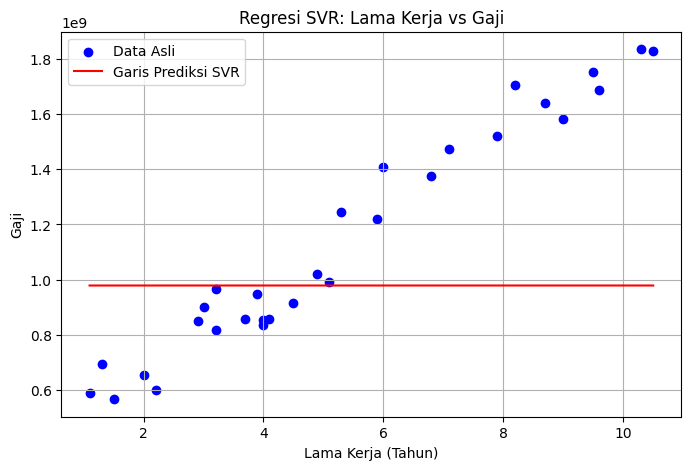

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

try:
    # 1. Membaca dataset dengan penyesuaian delimiter titik koma (;)
    data = pd.read_csv('Salary_Data.csv', delimiter=';')

    # 2. Menampilkan info dan 5 baris pertama
    print("--- Info Dataset ---")
    data.info()
    print("\n--- 5 Baris Pertama ---")
    display(data.head())

    # 3. Memisahkan atribut dan label dengan nama kolom yang benar
    X = data['Tahun_Pengalaman'].values
    y = data['Gaji'].values

    # Mengubah bentuk atribut X menjadi 2D array
    X = X[:, np.newaxis]

    # 4. Membangun dan melatih model SVR (C=1000, gamma=0.05, kernel='rbf')
    model = SVR(C=1000, gamma=0.05, kernel='rbf')
    model.fit(X, y)

    # 5. Memvisualisasikan hasil regresi
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color='blue', label='Data Asli')
    plt.plot(X, model.predict(X), color='red', label='Garis Prediksi SVR')
    plt.title('Regresi SVR: Lama Kerja vs Gaji')
    plt.xlabel('Lama Kerja (Tahun)')
    plt.ylabel('Gaji')
    plt.legend()
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("Error: File 'Salary_Data.csv' belum diunggah ke Colab.")

# Percobaan 3: Naïve Bayes Klasifikasi

--- 5 Baris Pertama Dataset Iklan Sosmed ---


,ID,Jenis_Kelamin,Umur,Gaji,Transaksi
0,15624510,Pria,19,285000000,0
1,15810944,Pria,35,300000000,0
2,15668575,Wanita,26,645000000,0
3,15603246,Wanita,27,855000000,0
4,15804002,Pria,19,1140000000,0



Akurasi Naïve Bayes: 87.50%
Confusion Matrix:
[[52  4]
 [ 6 18]]


/tmp/ipykernel_3873/4273383590.py:60: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


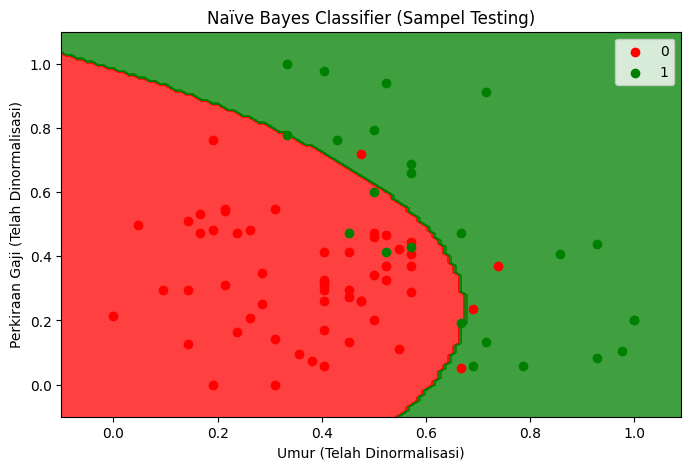

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap

try:
    # 1. Load dataset (pembatas delimiter ';')
    dataset = pd.read_csv('iklan_sosmed.csv', delimiter=';')
    print("--- 5 Baris Pertama Dataset Iklan Sosmed ---")
    display(dataset.head())

    # 2. Memisahkan fitur (Umur & Gaji) dan label (Transaksi)
    X = dataset.iloc[:, 2:-1]
    y = dataset.iloc[:, -1]

    # 3. Bagi data latih dan data uji (80:20, random_state=99)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

    # Konversi ke NumPy Array
    X_train = X_train.values
    y_train = y_train.values
    X_test = X_test.values
    y_test = y_test.values

    # 4. Normalisasi data dengan MinMaxScaler
    sc = MinMaxScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)

    # 5. Pelatihan model Gaussian Naïve Bayes
    classifier = GaussianNB()
    classifier.fit(X_train, y_train)

    # 6. Prediksi & Evaluasi (Confusion Matrix & Akurasi)
    y_pred = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print(f"\nAkurasi Naïve Bayes: {acc * 100:.2f}%")
    print("Confusion Matrix:")
    print(cm)

    # 7. Visualisasi Hasil Klasifikasi (Sampel Testing)
    X_set, y_set = X_test, y_test
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 0.1, stop=X_set[:, 0].max() + 0.1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 0.1, stop=X_set[:, 1].max() + 0.1, step=0.01)
    )
    plt.figure(figsize=(8, 5))
    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha=0.75, cmap=ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c=ListedColormap(('red', 'green'))(i), label=j)

    plt.title('Naïve Bayes Classifier (Sampel Testing)')
    plt.xlabel('Umur (Telah Dinormalisasi)')
    plt.ylabel('Perkiraan Gaji (Telah Dinormalisasi)')
    plt.legend()
    plt.show()

except FileNotFoundError:
    print("Error: File 'iklan_sosmed.csv' belum diunggah ke Colab.")

# Tuning Parameter SVM & SVR (Tugas Praktikum 1)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC, SVR
from sklearn.metrics import r2_score

# --- A. Tuning SVM (Klasifikasi Diabetes) ---
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train) # Menggunakan X_train dan y_train dari Percobaan 1

print("--- Parameter Terbaik SVM ---")
print("Best Parameters:", grid_svm.best_params_)
print("Best Accuracy Score:", grid_svm.best_score_ * 100, "%")


# --- B. Tuning SVR (Regresi Gaji) ---
param_grid_svr = {
    'C': [1, 100, 1000, 10000, 50000],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}

grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2')
grid_svr.fit(X, y) # Menggunakan X dan y dari Percobaan 2

print("\n--- Parameter Terbaik SVR ---")
print("Best Parameters:", grid_svr.best_params_)
print("Best R2 Score:", grid_svr.best_score_)

--- Parameter Terbaik SVM ---
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy Score: 90.9375 %


# Tuning Parameter Naïve Bayes (Tugas Praktikum 2)

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

# Parameter var_smoothing digunakan untuk kestabilan kalkulasi probabilitas
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy')
grid_nb.fit(X_train, y_train) # Menggunakan data Percobaan 3

print("--- Hyperparameter Tuning Naïve Bayes ---")
print("Best Parameter (var_smoothing):", grid_nb.best_params_)
print(f"Akurasi Optimal Naïve Bayes: {grid_nb.best_score_ * 100:.2f}%")

--- Hyperparameter Tuning Naïve Bayes ---
Best Parameter (var_smoothing): {'var_smoothing': np.float64(0.008111308307896872)}
Akurasi Optimal Naïve Bayes: 89.69%
